In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-shows/netflix_titles.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
import keras
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.layers import Input, Embedding, LSTM, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from keras.models import Model
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from tqdm import tqdm

In [3]:
df = pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.isna().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [5]:
df['Genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])
df['Genre']

0       International TV Shows
1                       Dramas
2                Horror Movies
3           Action & Adventure
4                       Dramas
                 ...          
7782                    Dramas
7783                    Dramas
7784             Documentaries
7785    International TV Shows
7786             Documentaries
Name: Genre, Length: 7787, dtype: object

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


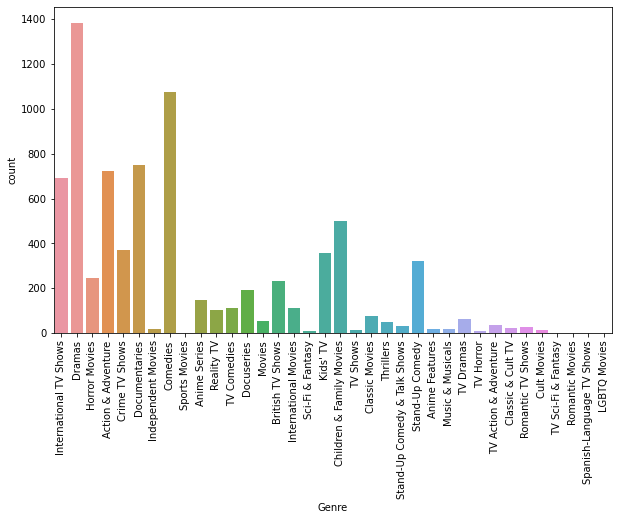

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(df['Genre'])
plt.xticks(rotation=90)
plt.show()

In [7]:
genre = ['Dramas','Comedies','Documentaries','Action & Adventure','International TV Shows']
len(df[df.Genre.isin(genre)])/len(df)

0.5932965198407603

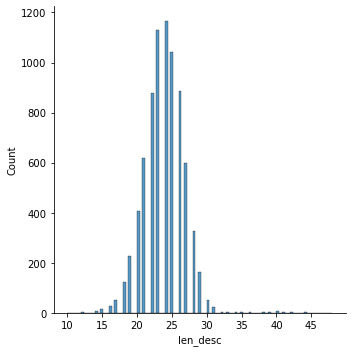

In [8]:
df['len_desc'] = df['description'].apply(lambda x: len(x.split(' ')))
sns.displot(df['len_desc'])

In [9]:
data = df[df.Genre.isin(genre)][['Genre','description']]
data

,Genre,description
0,International TV Shows,In a future where the elite inhabit an island ...
1,Dramas,After a devastating earthquake hits Mexico Cit...
3,Action & Adventure,"In a postapocalyptic world, rag-doll robots hi..."
4,Dramas,A brilliant group of students become card-coun...
5,International TV Shows,A genetics professor experiments with a treatm...
...,...,...
7782,Dramas,When Lebanon's Civil War deprives Zozo of his ...
7783,Dramas,A scrappy but poor boy worms his way into a ty...
7784,Documentaries,"In this documentary, South African rapper Nast..."
7785,International TV Shows,Dessert wizard Adriano Zumbo looks for the nex...


In [10]:
X = data['description']
y = data['Genre']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,stratify=y)

In [11]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['description'])
train_sequences = tokenizer.texts_to_sequences(X_train)
train_padded_seq = pad_sequences(train_sequences,maxlen=25,padding='post')
vocab_size = len(tokenizer.word_index)

In [12]:
test_sequences = tokenizer.texts_to_sequences(X_test)
test_padded_seq = pad_sequences(test_sequences,maxlen=25,padding='post')

In [13]:
le = LabelEncoder()
train_labels = le.fit_transform(y_train)
train_labels = to_categorical(train_labels)
test_labels = le.transform(y_test)
test_labels = to_categorical(test_labels)
le.classes_

array(['Action & Adventure', 'Comedies', 'Documentaries', 'Dramas',
       'International TV Shows'], dtype=object)

In [14]:
inputs = Input(shape=(25,))
embedding = Embedding(vocab_size+1,50)(inputs)
lstm1 = LSTM(50,return_sequences=True)(embedding)
dropout1 = Dropout(0.2)(lstm1)
lstm2 = LSTM(50,return_sequences=True)(dropout1)
dropout2 = Dropout(0.2)(lstm2)
lstm3 = LSTM(50)(dropout2)
dropout3 = Dropout(0.2)(lstm3)
outputs = Dense(len(le.classes_),activation='softmax')(dropout3)
model = Model(inputs,outputs)
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 25)]              0         
_________________________________________________________________
embedding (Embedding)        (None, 25, 50)            700700    
_________________________________________________________________
lstm (LSTM)                  (None, 25, 50)            20200     
_________________________________________________________________
dropout (Dropout)            (None, 25, 50)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 25, 50)            20200     
_________________________________________________________________
dropout_1 (Dropout)          (None, 25, 50)            0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 50)                20200 

In [15]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(train_padded_seq,train_labels,epochs=100,batch_size=32,validation_split=0.1)

Epoch 1/100
91/91 [==============================] - 11s 69ms/step - loss: 1.5507 - accuracy: 0.3120 - val_loss: 1.4063 - val_accuracy: 0.3981
Epoch 2/100
91/91 [==============================] - 5s 50ms/step - loss: 1.2116 - accuracy: 0.4439 - val_loss: 1.4068 - val_accuracy: 0.4136
Epoch 3/100
91/91 [==============================] - 5s 52ms/step - loss: 0.9360 - accuracy: 0.5830 - val_loss: 1.5571 - val_accuracy: 0.3549
Epoch 4/100
91/91 [==============================] - 5s 51ms/step - loss: 0.6195 - accuracy: 0.7451 - val_loss: 1.8210 - val_accuracy: 0.3426
Epoch 5/100
91/91 [==============================] - 5s 52ms/step - loss: 0.3486 - accuracy: 0.8818 - val_loss: 2.1803 - val_accuracy: 0.3179
Epoch 6/100
91/91 [==============================] - 5s 52ms/step - loss: 0.1814 - accuracy: 0.9493 - val_loss: 2.4208 - val_accuracy: 0.3302
Epoch 7/100
91/91 [==============================] - 5s 52ms/step - loss: 0.1144 - accuracy: 0.9703 - val_loss: 3.0316 - val_accuracy: 0.3241
Epoch

In [16]:
y_pred = [np.argmax(model.predict(test_padded_seq)[i]) for i in tqdm(range(len(test_padded_seq)))]

100%|██████████| 1386/1386 [12:43<00:00,  1.81it/s]


In [17]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

confusion_matrix(np.argmax(y_test,-1),y_pred)

TypeError: Singleton array 0 cannot be considered a valid collection.